Team Members:
- Daisy Kudzai Tsenesa
- Nonzuzo Sylvia Sikhosana
- Stanley Tulani Ndlovu
- Adelard Borauzima

#Install libraries and import basics

In [ ]:

!pip install -q simpy opendatasets

import opendatasets as od
import pandas as pd
import numpy as np
import simpy
from scipy import stats as scipy_stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

Download Kaggle dataset and load CSV

In [ ]:


# This will ask for Kaggle username and API key (from Kaggle > Settings > API)
od.download("https://www.kaggle.com/datasets/ilkeryildiz/emergency-service-triage-application")

# The data is in the folder created by opendatasets
data_path = "emergency-service-triage-application/data.csv"

df = pd.read_csv(
    data_path,
    sep=";",          # semicolon-separated
    encoding="latin1" # handles weird characters
)

print("Shape:", df.shape)
print(df.head(3))
print("\nColumns:", df.columns.tolist())

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle Key:


Abort: 

# Rename columns and convert basic types

In [ ]:


df.rename(columns={
    "Group":                  "ed_type",
    "Sex":                    "sex",
    "Age":                    "age",
    "Patients number per hour": "patients_per_hour",
    "Arrival mode":           "arrival_mode",
    "Injury":                 "injury",
    "Chief_complain":         "chief_complaint",
    "Mental":                 "mental",
    "Pain":                   "pain",
    "NRS_pain":               "nrs_pain",
    "SBP":                    "sbp",
    "DBP":                    "dbp",
    "HR":                     "hr",
    "RR":                     "rr",
    "BT":                     "bt",
    "Saturation":             "spo2",
    "KTAS_RN":                "ktas_nurse",
    "Diagnosis in ED":        "diagnosis",
    "Disposition":            "disposition",
    "KTAS_expert":            "ktas",
    "Error_group":            "error_group",
    "Length of stay_min":     "los_min",
    "KTAS duration_min":      "triage_duration_min",
    "mistriage":              "mistriage"
}, inplace=True)

# Fix decimal comma in triage_duration_min
df["triage_duration_min"] = (
    df["triage_duration_min"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Core numerics
df["los_min"]           = pd.to_numeric(df["los_min"], errors="coerce")
df["patients_per_hour"] = pd.to_numeric(df["patients_per_hour"], errors="coerce")

int_cols = [
    "ed_type","sex","age","arrival_mode","injury","mental","pain",
    "ktas_nurse","disposition","ktas","error_group","mistriage"
]
for col in int_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)

ed_type                  int64
sex                      int64
age                      int64
patients_per_hour        int64
arrival_mode             int64
injury                   int64
chief_complaint         object
mental                   int64
pain                     int64
nrs_pain                object
sbp                     object
dbp                     object
hr                      object
rr                      object
bt                      object
spo2                    object
ktas_nurse               int64
diagnosis               object
disposition              int64
ktas                     int64
error_group              int64
los_min                  int64
triage_duration_min    float64
mistriage                int64
dtype: object


# Clean missing values and drop LOS outliers

In [ ]:


# Vital signs to numeric
vital_cols = ["sbp","dbp","hr","rr","bt","spo2"]
for col in vital_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Missing before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Drop spo2 (lots missing)
df.drop(columns=["spo2"], inplace=True)

# nrs_pain: fill with 0
df["nrs_pain"] = df["nrs_pain"].fillna(0)

# Vitals: fill with median
for col in ["sbp","dbp","hr","rr","bt"]:
    df[col] = df[col].fillna(df[col].median())

# Diagnosis: fill with "Unknown"
df["diagnosis"] = df["diagnosis"].fillna("Unknown")

print("\nMissing after fills (before LOS filter):")
print(df.isnull().sum()[df.isnull().sum() > 0])

# LOS: keep (0, 1440] minutes
before = len(df)
df_clean = df[(df["los_min"] > 0) & (df["los_min"] <= 1440)].copy()
print(f"\nRows before LOS filter: {before}")
print(f"Rows after  LOS filter: {len(df_clean)}")

print("\nLOS by KTAS (first look):")
print(df_clean.groupby("ktas")["los_min"].describe().round(2))

Missing before cleaning:
sbp           25
dbp           29
hr            20
rr            22
bt            18
spo2         697
diagnosis      2
dtype: int64

Missing after fills (before LOS filter):
Series([], dtype: int64)

Rows before LOS filter: 1267
Rows after  LOS filter: 1055

LOS by KTAS (first look):
      count    mean     std   min    25%    50%    75%     max
ktas                                                          
1      23.0  295.52  220.50  35.0  130.5  272.0  400.0  1010.0
2     157.0  416.43  280.13   1.0  222.0  363.0  542.0  1388.0
3     397.0  352.98  283.10  21.0  157.0  275.0  436.0  1439.0
4     405.0  242.99  224.50   4.0   83.0  174.0  332.0  1318.0
5      73.0  177.82  187.27  12.0   59.0  122.0  195.0   972.0


# Map KTAS → SATS and compute acuity mix

In [ ]:

ktas_to_sats = {1: "Red", 2: "Orange", 3: "Yellow", 4: "Green", 5: "Green"}
df_clean["sats"] = df_clean["ktas"].map(ktas_to_sats)

# Explicitly overwrite the 'sats' column to say "Blue" for patients who died
df_clean.loc[df_clean["disposition"] == 6, "sats"] = "Blue"

print("SATS distribution:")
# Now this will correctly include Blue in the printed table
sats_counts = df_clean["sats"].value_counts()
sats_pct    = (sats_counts / len(df_clean) * 100).round(2)
print(pd.DataFrame({"count": sats_counts, "percent_%": sats_pct}))

# Calculate the mix directly from the updated column
ACUITY_MIX = {
    "Red":    (df_clean["sats"] == "Red").mean(),
    "Orange": (df_clean["sats"] == "Orange").mean(),
    "Yellow": (df_clean["sats"] == "Yellow").mean(),
    "Green":  (df_clean["sats"] == "Green").mean(),
    "Blue":   (df_clean["sats"] == "Blue").mean()
}

print("\nACUITY_MIX:", ACUITY_MIX)

# Normalize sum to 1.0
total_prob = sum(ACUITY_MIX.values())
ACUITY_MIX = {k: v / total_prob for k, v in ACUITY_MIX.items()}

SATS distribution:
        count  percent_%
sats                    
Green     478      45.31
Yellow    397      37.63
Orange    157      14.88
Red        16       1.52
Blue        7       0.66

ACUITY_MIX: {'Red': np.float64(0.015165876777251185), 'Orange': np.float64(0.14881516587677726), 'Yellow': np.float64(0.376303317535545), 'Green': np.float64(0.45308056872037916), 'Blue': np.float64(0.006635071090047393)}


# Build inhomogeneous 24-hour arrival rates

In [ ]:

rate_mean = df_clean["patients_per_hour"].mean()

# Create an array of 24 hours [0, 1, 2 ... 23]
hours = np.arange(24)

# Generate a bell curve centered at hour 17 (5:00 PM) with a standard deviation of 4 hours
# This creates a natural build-up and cool-down of patient traffic
pdf_curve = scipy_stats.norm.pdf(hours, loc=17, scale=4)

# Scale the curve so that the average of these 24 hours exactly matches our Kaggle dataset mean
scale_factor = rate_mean / pdf_curve.mean()
HOURLY_ARRIVAL_RATES = (pdf_curve * scale_factor)

# Ensure no hour drops below a minimum of 0.5 patients/hour (ERs are never totally empty)
HOURLY_ARRIVAL_RATES = np.clip(HOURLY_ARRIVAL_RATES, a_min=0.5, a_max=None).round(2)

print("Dynamic Numpy Arrival Rates (Patients/Hr):")
print(HOURLY_ARRIVAL_RATES)

Dynamic Numpy Arrival Rates (Patients/Hr):
[ 0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.84  1.52  2.59  4.14  6.22
  8.77 11.62 14.46 16.91 18.57 19.16 18.57 16.91 14.46 11.62  8.77  6.22]


# Service-time distributions (using previous fitted parameters)

In [ ]:

TREATMENT_FRACTION = 0.20
DISTRIBUTIONS_TO_TEST = [scipy_stats.expon, scipy_stats.gamma, scipy_stats.lognorm]
FITTED_SERVICE_DISTRIBUTIONS = {}

print("\n--- Running Goodness-of-Fit Tests (MLE) for Service Times ---")
for sats in ["Red", "Orange", "Yellow", "Green", "Blue"]:

    if sats == "Blue":
        # Specific LOS data for patients who died
        data = df_clean[df_clean["disposition"] == 6]["los_min"].dropna().values
    else:
        data = df_clean[df_clean["sats"] == sats]["los_min"].dropna().values * TREATMENT_FRACTION

    if len(data) < 5:
        FITTED_SERVICE_DISTRIBUTIONS[sats] = ("expon", (0, 5.0))
        print(f"Acuity {sats:<6} | Not enough data, defaulting to Exponential")
        continue

    best_dist = "lognorm"
    best_p = -1
    best_params = None

    for dist in DISTRIBUTIONS_TO_TEST:
        params = dist.fit(data)
        d_stat, p_val = scipy_stats.kstest(data, dist.name, args=params)

        if p_val > best_p:
            best_p = p_val
            best_dist = dist.name
            best_params = params

    if best_params is None:
        best_params = scipy_stats.lognorm.fit(data)

    FITTED_SERVICE_DISTRIBUTIONS[sats] = (best_dist, best_params)
    print(f"Acuity {sats:<6} | Best Fit: {best_dist:<8} | KS p-value: {best_p:.4f}")


--- Running Goodness-of-Fit Tests (MLE) for Service Times ---
Acuity Red    | Best Fit: expon    | KS p-value: 0.9347
Acuity Orange | Best Fit: lognorm  | KS p-value: 0.6523
Acuity Yellow | Best Fit: lognorm  | KS p-value: 0.9248
Acuity Green  | Best Fit: lognorm  | KS p-value: 0.7664
Acuity Blue   | Best Fit: expon    | KS p-value: 0.7718


# Triage time, priorities, patience, staffing

In [ ]:

SATS_PRIORITY = {"Red":1, "Orange":2, "Yellow":3, "Green":4, "Blue":5}
TRIAGE_TIME_MEAN = df_clean["triage_duration_min"].mean()
print("Mean triage duration:", TRIAGE_TIME_MEAN)


# the max time that each coded patient can wait without being seen
LWBS_PATIENCE_TRIAGE = {"Red": 2, "Orange": 10, "Yellow": 30, "Green": 60, "Blue": 999}
LWBS_PATIENCE_BAY    = {"Red": 15, "Orange": 60, "Yellow": 120, "Green": 240, "Blue": 999}

STAFFING = {
    "weekday": {"triage_nurses":3, "treatment_bays":12},
    "weekend": {"triage_nurses":2, "treatment_bays": 8},
}
ADMIT_PROB = {"Red":0.70, "Orange":0.45, "Yellow":0.20, "Green":0.05}
SIM_DURATION = 24 * 60
REPLICATIONS = 30
RANDOM_SEED  = 42

class Patient:
    _ctr = 0
    def __init__(self, acuity, t):
        Patient._ctr += 1
        self.id = Patient._ctr
        self.acuity = acuity
        self.priority = SATS_PRIORITY[acuity]
        self.arrival = t
        self.triage_start = None
        self.doctor_start = None
        self.doctor_end = None
        self.departure = None
        self.lwbs = False
        self.outcome = None

Mean triage duration: 5.878947867298578


# Sample service time from fitted distributions

In [ ]:


def sample_service_time(acuity, rng):
    dist_name, params = FITTED_SERVICE_DISTRIBUTIONS[acuity]
    dist = getattr(scipy_stats, dist_name)
    return max(1.0, float(dist.rvs(*params, random_state=int(rng.integers(0, 1e9)))))

# Core SimPy simulation (one replication)

In [ ]:

def run_simulation(staffing, policy, seed):
    Patient._ctr = 0
    rng = np.random.default_rng(seed)
    env = simpy.Environment()
    staff = STAFFING[staffing]

    nurses  = simpy.PreemptiveResource(env, capacity=staff["triage_nurses"])
    bays    = simpy.PriorityResource(env,   capacity=staff["treatment_bays"])
    ft_bays = simpy.PriorityResource(env,   capacity=max(1, staff["treatment_bays"] // 3))

    patient_log = []
    monitor_log = []

    def select_bay(p):
        if policy == "fast_track" and p.acuity == "Green": return ft_bays
        if policy == "split_flow" and p.acuity in ("Yellow","Green"): return ft_bays
        return bays

    def monitor():
        """Background process to sample queue lengths and resource utilization every 5 mins"""
        while True:
            q_counts = {1:0, 2:0, 3:0, 4:0, 5:0}
            for req in bays.queue:
                q_counts[req.priority] += 1

            monitor_log.append({
                "time": env.now,
                "nurse_queue_len": len(nurses.queue),
                "bay_queue_len": len(bays.queue),
                "nurse_utilization": nurses.count / nurses.capacity,
                "bay_utilization": bays.count / bays.capacity,
                "q_Red": q_counts[1], "q_Orange": q_counts[2],
                "q_Yellow": q_counts[3], "q_Green": q_counts[4]
            })
            yield env.timeout(5)

    def patient_journey(p):
        triage_patience = LWBS_PATIENCE_TRIAGE[p.acuity]
        bay_patience    = LWBS_PATIENCE_BAY[p.acuity]

        # Stage 1: Preemptive Triage
        triage_done = False
        while not triage_done:
            with nurses.request(priority=p.priority, preempt=True) as req:
                result = yield req | env.timeout(triage_patience)
                if req not in result:
                    p.lwbs = True
                    patient_log.append(vars(p).copy())
                    return
                p.triage_start = env.now
                try:
                    yield env.timeout(rng.exponential(TRIAGE_TIME_MEAN))
                    triage_done = True
                except simpy.Interrupt:
                    pass # Bumped by higher priority, re-queue

        if p.acuity == "Blue":
            p.departure, p.outcome = env.now, "DOA"
            patient_log.append(vars(p).copy())
            return

        # Stage 2: Treatment Bays
        pool = select_bay(p)
        with pool.request(priority=p.priority) as req:
            result = yield req | env.timeout(bay_patience)
            if req not in result:
                p.lwbs = True
                patient_log.append(vars(p).copy())
                return
            p.doctor_start = env.now
            yield env.timeout(sample_service_time(p.acuity, rng))
            p.doctor_end = env.now

        p.departure = env.now
        p.outcome = "admitted" if rng.random() < ADMIT_PROB.get(p.acuity, 0.05) else "discharged"
        patient_log.append(vars(p).copy())

    def arrivals():
        while True:
            h = int(env.now // 60) % 24
            inter = rng.exponential(1.0 / (HOURLY_ARRIVAL_RATES[h] / 60.0))
            yield env.timeout(inter)
            acuity = rng.choice(list(ACUITY_MIX.keys()), p=list(ACUITY_MIX.values()))
            env.process(patient_journey(Patient(acuity, env.now)))

    env.process(arrivals())
    env.process(monitor())
    env.run(until=SIM_DURATION)

    return pd.DataFrame(patient_log), pd.DataFrame(monitor_log)

# Run all 6 scenarios and collect results

In [ ]:


SCENARIOS = [
    ("weekday","base"), ("weekend","base"),
    ("weekday","fast_track"), ("weekend","fast_track"),
    ("weekday","split_flow"), ("weekend","split_flow"),
]

all_patient_results = {}
all_monitor_results = {}

print("\n--- Running Simulation Scenarios ---")
for staffing, policy in SCENARIOS:
    label = f"{staffing}_{policy}"
    reps_p, reps_m = [], []
    for rep in range(REPLICATIONS):
        df_p, df_m = run_simulation(staffing, policy, RANDOM_SEED + rep)
        df_p["rep"], df_m["rep"] = rep, rep
        reps_p.append(df_p); reps_m.append(df_m)

    all_patient_results[label] = pd.concat(reps_p, ignore_index=True)
    all_monitor_results[label] = pd.concat(reps_m, ignore_index=True)
    print(f"Completed {REPLICATIONS} replications for: {label}")

print("\nAll scenarios complete.")


--- Running Simulation Scenarios ---
Completed 30 replications for: weekday_base
Completed 30 replications for: weekend_base
Completed 30 replications for: weekday_fast_track
Completed 30 replications for: weekend_fast_track
Completed 30 replications for: weekday_split_flow
Completed 30 replications for: weekend_split_flow

All scenarios complete.


# Outputs: Face Validity, Queue Stats, Overall KPIs

In [ ]:

print("\n" + "="*50)
print(" FACE VALIDITY: Empirical vs Simulated")
print("="*50)
empirical_los = df_clean['los_min'].mean()
sim_df = all_patient_results["weekday_base"]
sim_completed = sim_df[sim_df["departure"].notna()]
sim_los = (sim_completed["departure"] - sim_completed["arrival"]).mean()

print(f"Empirical Mean Length of Stay (Dataset):  {empirical_los:.2f} mins")
print(f"Simulated Mean Length of Stay (WD Base):  {sim_los:.2f} mins")


 FACE VALIDITY: Empirical vs Simulated
Empirical Mean Length of Stay (Dataset):  306.83 mins
Simulated Mean Length of Stay (WD Base):  103.88 mins


In [ ]:
print("\n" + "="*50)
print(" QUEUE DISTRIBUTIONS (Treatment Bays - Weekday Base)")
print("="*50)
mon_df = all_monitor_results["weekday_base"]
q_lens = mon_df["bay_queue_len"]

print(f"Frequency Queue is exactly 0 patients:  {(q_lens == 0).mean() * 100:.1f}%")
print(f"Frequency Queue is exactly 2 patients:  {(q_lens == 2).mean() * 100:.1f}%")
print(f"Frequency Queue is >= 10 patients:      {(q_lens >= 10).mean() * 100:.1f}%")
print(f"Average Queue Length:                   {q_lens.mean():.2f} patients")
print(f"90th Percentile Queue Length:           {q_lens.quantile(0.90):.0f} patients")
print(f"Maximum Queue Length:                   {q_lens.max():.0f} patients")


 QUEUE DISTRIBUTIONS (Treatment Bays - Weekday Base)
Frequency Queue is exactly 0 patients:  61.3%
Frequency Queue is exactly 2 patients:  0.8%
Frequency Queue is >= 10 patients:      31.6%
Average Queue Length:                   9.12 patients
90th Percentile Queue Length:           33 patients
Maximum Queue Length:                   70 patients


In [ ]:
print("\nResource Utilization (Weekday Base):")
print(f"Triage Nurse Utilization: {mon_df['nurse_utilization'].mean() * 100:.1f}%")
print(f"Treatment Bay Utilization: {mon_df['bay_utilization'].mean() * 100:.1f}%\n")


Resource Utilization (Weekday Base):
Triage Nurse Utilization: 24.1%
Treatment Bay Utilization: 49.0%



# Overall KPI summary per scenario

In [ ]:

rows = []
for label, df_sim in all_patient_results.items():
    seen = df_sim[df_sim["doctor_start"].notna()].copy()
    seen["dtd"] = seen["doctor_start"] - seen["arrival"]
    rows.append({
        "scenario": label,
        "lwbs_rate": df_sim["lwbs"].mean(),
        "dtd_mean": seen["dtd"].mean(),
        "prob_over_30": (seen["dtd"] > 30).mean()
    })

kpi_summary = pd.DataFrame(rows)
print("="*50)
print(" OVERALL KPI SUMMARY")
print("="*50)
print(kpi_summary.to_string(index=False))


 OVERALL KPI SUMMARY
          scenario  lwbs_rate  dtd_mean  prob_over_30
      weekday_base   0.160035 42.613553      0.337477
      weekend_base   0.406879 42.725734      0.412196
weekday_fast_track   0.023588 42.596063      0.371505
weekend_fast_track   0.264904 67.861520      0.496329
weekday_split_flow   0.477243 42.459137      0.415021
weekend_split_flow   0.624197 38.132281      0.326467


# KPI table by scenario and SATS acuity

In [ ]:


rows = []
for label, df_sim in all_patient_results.items():
    seen = df_sim[df_sim["doctor_start"].notna()].copy()
    seen["dtd"] = seen["doctor_start"] - seen["arrival"]
    for acuity in ["Red","Orange","Yellow","Green", "Blue"]:
        acuity_all  = df_sim[df_sim["acuity"] == acuity]
        acuity_seen = seen[seen["acuity"] == acuity]
        rows.append({
            "scenario":   label,
            "acuity":     acuity,
            "n_patients": len(acuity_all),
            "n_seen":     len(acuity_seen),
            "lwbs_rate":  acuity_all["lwbs"].mean(),
            "dtd_mean":   acuity_seen["dtd"].mean() if len(acuity_seen) > 0 else None,
            "dtd_p90":    acuity_seen["dtd"].quantile(0.90) if len(acuity_seen) > 0 else None,
            "dtd_max":    acuity_seen["dtd"].max() if len(acuity_seen) > 0 else None,
            "prob_over_30": (acuity_seen["dtd"] > 30).mean() if len(acuity_seen) > 0 else None,
        })

kpi_by_acuity = pd.DataFrame(rows)
print("KPI by scenario and SATS acuity:\n")
print(kpi_by_acuity)

KPI by scenario and SATS acuity:

              scenario  acuity  n_patients  n_seen  lwbs_rate    dtd_mean  \
0         weekday_base     Red          82      73   0.109756   10.214341   
1         weekday_base  Orange         772     772   0.000000   10.938920   
2         weekday_base  Yellow        1851    1810   0.022150   32.036325   
3         weekday_base   Green        1804    1126   0.375831   83.433039   
4         weekday_base    Blue          40       0   0.000000         NaN   
5         weekend_base     Red          77      57   0.259740    9.756384   
6         weekend_base  Orange         763     759   0.005242   16.167562   
7         weekend_base  Yellow        1798    1313   0.269744   63.087596   
8         weekend_base   Green        1751     462   0.736151   32.556427   
9         weekend_base    Blue          30       0   0.000000         NaN   
10  weekday_fast_track     Red          80      78   0.025000    8.307414   
11  weekday_fast_track  Orange         759

# Weekend base — find minimum bays to keep LWBS < 5%

In [ ]:

LWBS_TARGET = 0.05
print("\n--- Testing weekend base bay requirements for LWBS < 5% ---")
for n_bays in range(8, 21):
    STAFFING["weekend"]["treatment_bays"] = n_bays
    reps = []
    for rep in range(10): # Reduced reps for faster search
        df_p, _ = run_simulation("weekend", "base", RANDOM_SEED + rep)
        reps.append(df_p)
    combined = pd.concat(reps, ignore_index=True)
    lwbs = combined["lwbs"].mean()
    print(f"Bays: {n_bays:<2} | LWBS: {lwbs:>6.2%}")
    if lwbs <= LWBS_TARGET:
        print(f"--> Minimum weekend bays needed: {n_bays}")
        break
STAFFING["weekend"]["treatment_bays"] = 8 # Restore baseline


--- Testing weekend base bay requirements for LWBS < 5% ---
Bays: 8  | LWBS: 38.88%
Bays: 9  | LWBS: 34.90%
Bays: 10 | LWBS: 29.26%
Bays: 11 | LWBS: 20.90%
Bays: 12 | LWBS: 13.46%
Bays: 13 | LWBS: 10.18%
Bays: 14 | LWBS:  5.71%
Bays: 15 | LWBS:  0.65%
--> Minimum weekend bays needed: 15


# LWBS and P(DTD>30) bar charts

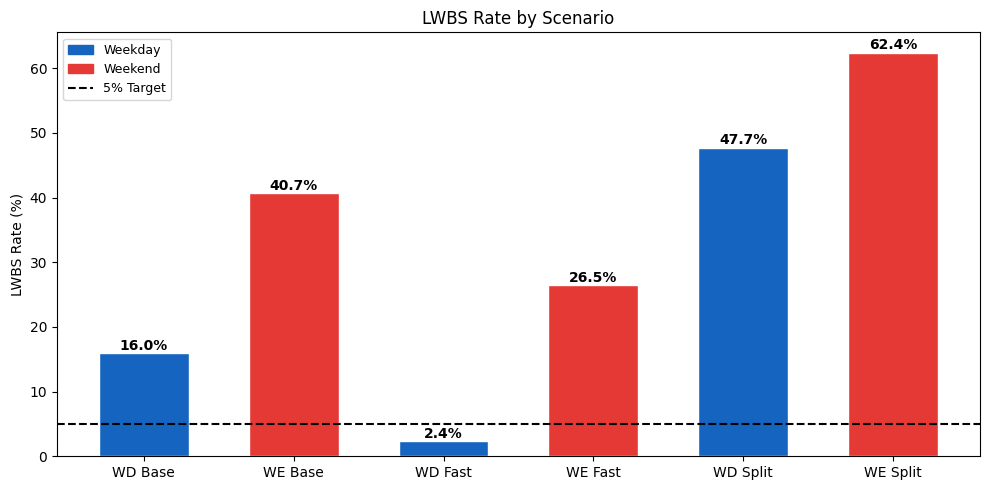

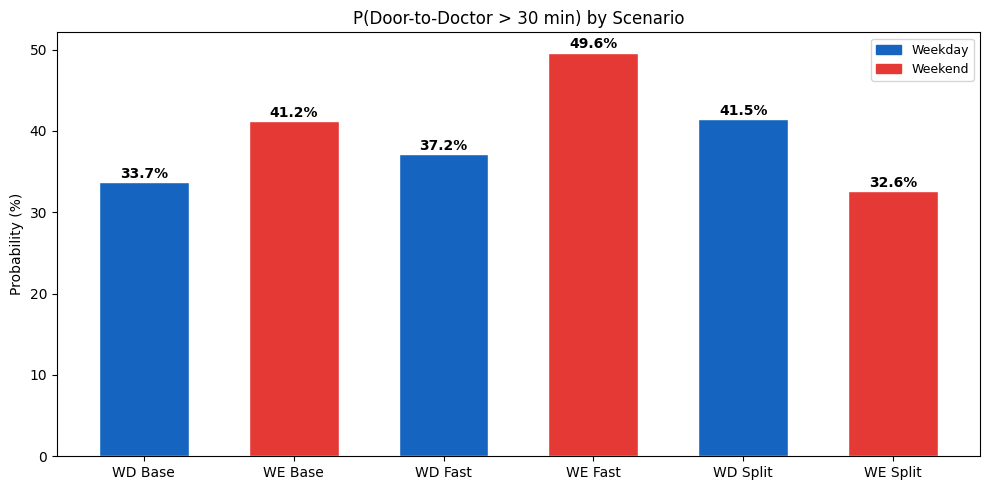

In [ ]:


import matplotlib.patches as mpatches

SCENARIO_SHORT = {
    "weekday_base":       "WD Base",
    "weekend_base":       "WE Base",
    "weekday_fast_track": "WD Fast",
    "weekend_fast_track": "WE Fast",
    "weekday_split_flow": "WD Split",
    "weekend_split_flow": "WE Split",
}
scenarios    = list(all_patient_results.keys())
short_labels = [SCENARIO_SHORT[s] for s in scenarios]

# Weekday = blue, Weekend = red
bar_colors = ["#1565C0","#E53935","#1565C0","#E53935","#1565C0","#E53935"]
wd_patch   = mpatches.Patch(color="#1565C0", label="Weekday")
we_patch   = mpatches.Patch(color="#E53935", label="Weekend")

# LWBS
fig, ax = plt.subplots(figsize=(10, 5))
lwbs_vals = [all_patient_results[s]["lwbs"].mean()*100 for s in scenarios]
bars = ax.bar(short_labels, lwbs_vals, color=bar_colors, edgecolor="white", width=0.6)
ax.axhline(5, color="black", linestyle="--", lw=1.5, label="5% Target")
for bar, val in zip(bars, lwbs_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("LWBS Rate (%)")
ax.set_title("LWBS Rate by Scenario")
ax.legend(handles=[wd_patch, we_patch,
          plt.Line2D([0],[0], color="black", linestyle="--", label="5% Target")],
          fontsize=9)
plt.tight_layout()
plt.show()

# P(DTD > 30)
fig, ax = plt.subplots(figsize=(10, 5))
prob_vals = []
for s in scenarios:
    df_sim = all_patient_results[s]
    seen   = df_sim[df_sim["doctor_start"].notna()].copy()
    seen["dtd"] = seen["doctor_start"] - seen["arrival"]
    prob_vals.append((seen["dtd"] > 30).mean()*100)
bars = ax.bar(short_labels, prob_vals, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, prob_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Probability (%)")
ax.set_title("P(Door-to-Doctor > 30 min) by Scenario")
ax.legend(handles=[wd_patch, we_patch], fontsize=9)
plt.tight_layout()
plt.show()

# DTD boxplots by SATS for weekday vs weekend base

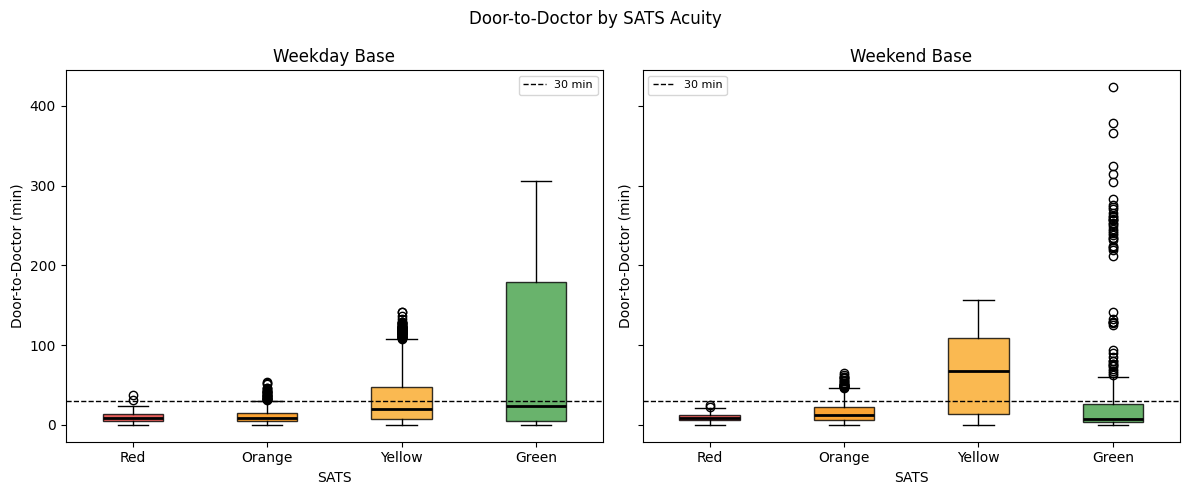

In [ ]:


SATS_COLORS = {"Red":"#E53935","Orange":"#FB8C00","Yellow":"#F9A825","Green":"#43A047"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, scenario, title in zip(
    axes,
    ["weekday_base", "weekend_base"],
    ["Weekday Base", "Weekend Base"]
):
    df_sim = all_patient_results[scenario]
    seen   = df_sim[df_sim["doctor_start"].notna()].copy()
    seen["dtd"] = seen["doctor_start"] - seen["arrival"]

    data   = [seen[seen["acuity"]==a]["dtd"].values for a in ["Red","Orange","Yellow","Green"]]
    colors = [SATS_COLORS[a] for a in ["Red","Orange","Yellow","Green"]]

    bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color="black", linewidth=2))
    for box, c in zip(bp["boxes"], colors):
        box.set_facecolor(c); box.set_alpha(0.8)

    ax.axhline(30, color="black", linestyle="--", lw=1, label="30 min")
    ax.set_xticklabels(["Red","Orange","Yellow","Green"])
    ax.set_title(title); ax.set_xlabel("SATS"); ax.set_ylabel("Door-to-Doctor (min)")
    ax.legend(fontsize=8)

fig.suptitle("Door-to-Doctor by SATS Acuity")
plt.tight_layout()
plt.show()

# DTD histograms by SATS — Weekday Base

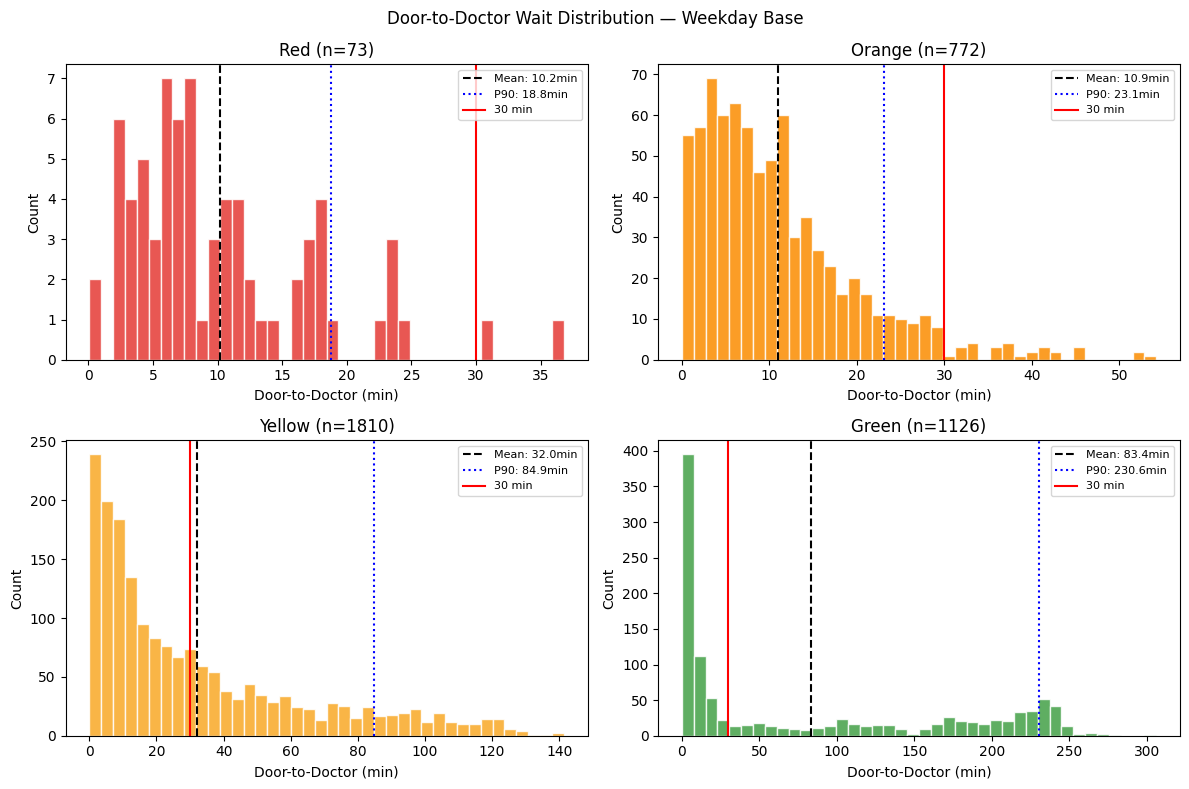

In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

df_wb = all_patient_results["weekday_base"]
seen  = df_wb[df_wb["doctor_start"].notna()].copy()
seen["dtd"] = seen["doctor_start"] - seen["arrival"]

for i, acuity in enumerate(["Red","Orange","Yellow","Green"]):
    data = seen[seen["acuity"]==acuity]["dtd"].values
    ax   = axes[i]
    ax.hist(data, bins=40, color=SATS_COLORS[acuity],
            edgecolor="white", alpha=0.85)
    ax.axvline(np.mean(data), color="black", linestyle="--",
               lw=1.5, label=f"Mean: {np.mean(data):.1f}min")
    ax.axvline(np.percentile(data, 90), color="blue", linestyle=":",
               lw=1.5, label=f"P90: {np.percentile(data,90):.1f}min")
    ax.axvline(30, color="red", lw=1.5, label="30 min")
    ax.set_title(f"{acuity} (n={len(data)})")
    ax.set_xlabel("Door-to-Doctor (min)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Door-to-Doctor Wait Distribution — Weekday Base")
plt.tight_layout()
plt.show()

# Sensitivity — triage misclassification ±1 (weekday base)

In [ ]:

UPGRADE_MAP   = {"Red":"Red","Orange":"Red","Yellow":"Orange","Green":"Yellow","Blue":"Blue"}
DOWNGRADE_MAP = {"Red":"Orange","Orange":"Yellow","Yellow":"Green","Green":"Green","Blue":"Blue"}

def run_simulation_misclassified(direction, seed):
    Patient._ctr = 0
    rng = np.random.default_rng(seed)
    env = simpy.Environment()
    staff = STAFFING["weekday"]
    nurses = simpy.PreemptiveResource(env, capacity=staff["triage_nurses"])
    bays = simpy.PriorityResource(env, capacity=staff["treatment_bays"])
    log = []

    def patient_journey(p):
        triage_done = False
        while not triage_done:
            with nurses.request(priority=p.priority, preempt=True) as req:
                result = yield req | env.timeout(LWBS_PATIENCE_TRIAGE[p.acuity])
                if req not in result:
                    p.lwbs = True
                    log.append(vars(p).copy()); return
                try:
                    yield env.timeout(rng.exponential(TRIAGE_TIME_MEAN))
                    triage_done = True
                except simpy.Interrupt: pass

        if p.acuity == "Blue": return
        with bays.request(priority=p.priority) as req:
            result = yield req | env.timeout(LWBS_PATIENCE_BAY[p.acuity])
            if req not in result:
                p.lwbs = True
                log.append(vars(p).copy()); return
            p.doctor_start = env.now
            yield env.timeout(sample_service_time(p.acuity, rng))
        log.append(vars(p).copy())

    def arrivals():
        while True:
            inter = rng.exponential(1.0 / (HOURLY_ARRIVAL_RATES[int(env.now//60)%24]/60.0))
            yield env.timeout(inter)
            true_acuity = rng.choice(list(ACUITY_MIX.keys()), p=list(ACUITY_MIX.values()))
            if direction == "upgrade": assigned = UPGRADE_MAP[true_acuity]
            elif direction == "downgrade": assigned = DOWNGRADE_MAP[true_acuity]
            else: assigned = true_acuity
            env.process(patient_journey(Patient(assigned, env.now)))

    env.process(arrivals())
    env.run(until=SIM_DURATION)
    return pd.DataFrame(log)

# --- Initialize the dictionary the charts need ---
results_sens = {}

print("\n--- Sensitivity: Triage Misclassification ±1 Level ---")
for cond, direct in [("Baseline", "none"), ("Upgrade +1", "upgrade"), ("Downgrade -1", "downgrade")]:
    reps = [run_simulation_misclassified(direct, RANDOM_SEED + r) for r in range(15)]
    df_sens = pd.concat(reps, ignore_index=True)

    # Save the dataframe into the dictionary!
    results_sens[cond] = df_sens

    seen = df_sens[df_sens["doctor_start"].notna()].copy()
    seen["dtd"] = seen["doctor_start"] - seen["arrival"]
    print(f"{cond:<15} LWBS: {df_sens['lwbs'].mean():.2%} | Mean DTD: {seen['dtd'].mean():.1f} min")


--- Sensitivity: Triage Misclassification ±1 Level ---
Baseline        LWBS: 16.59% | Mean DTD: 42.7 min
Upgrade +1      LWBS: 28.74% | Mean DTD: 26.9 min
Downgrade -1    LWBS: 0.18% | Mean DTD: 45.1 min


# Sensitivity bar chart

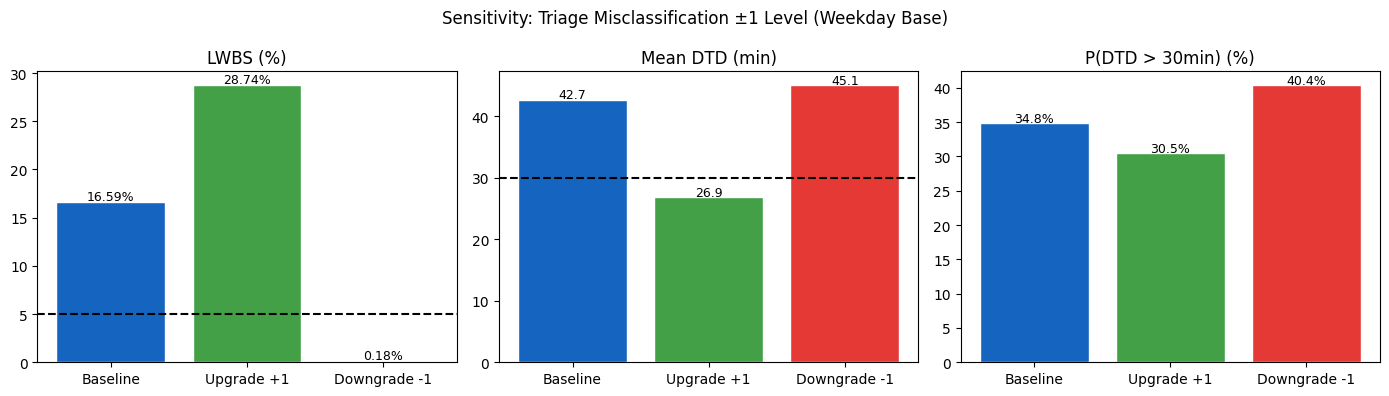

In [ ]:


conds = ["Baseline","Upgrade +1","Downgrade -1"]
colors = ["#1565C0","#43A047","#E53935"]

lwbs_vals = []
dtd_vals  = []
prob_vals = []

for c in conds:
    df_sim = results_sens[c]
    seen   = df_sim[df_sim["doctor_start"].notna()].copy()
    seen["dtd"] = seen["doctor_start"] - seen["arrival"]
    lwbs_vals.append(df_sim["lwbs"].mean()*100)
    dtd_vals.append(seen["dtd"].mean())
    prob_vals.append((seen["dtd"]>30).mean()*100)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# LWBS
axes[0].bar(conds, lwbs_vals, color=colors, edgecolor="white")
axes[0].axhline(5, color="black", linestyle="--", lw=1.5)
axes[0].set_title("LWBS (%)")
for i,v in enumerate(lwbs_vals):
    axes[0].text(i, v+0.2, f"{v:.2f}%", ha="center", fontsize=9)

# Mean DTD
axes[1].bar(conds, dtd_vals, color=colors, edgecolor="white")
axes[1].axhline(30, color="black", linestyle="--", lw=1.5)
axes[1].set_title("Mean DTD (min)")
for i,v in enumerate(dtd_vals):
    axes[1].text(i, v+0.2, f"{v:.1f}", ha="center", fontsize=9)

# P(DTD>30)
axes[2].bar(conds, prob_vals, color=colors, edgecolor="white")
axes[2].set_title("P(DTD > 30min) (%)")
for i,v in enumerate(prob_vals):
    axes[2].text(i, v+0.2, f"{v:.1f}%", ha="center", fontsize=9)

plt.suptitle("Sensitivity: Triage Misclassification ±1 Level (Weekday Base)")
plt.tight_layout()
plt.show()